# Análise Exploratória de Dados — NPS Preditivo

**Tech Challenge · Fase 1 — Pós-Tech AI Scientist (FIAP)**

Uma empresa de e-commerce percebeu que clientes parecidos dão notas de satisfação muito diferentes.
O NPS só é medido **depois** que a compra termina, então a empresa não consegue agir antes.

Este notebook explora os dados para responder quatro perguntas:

1. Quais fatores são mais críticos para a satisfação?
2. O que mais gera clientes detratores?
3. Existe um "ponto de ruptura" na experiência do cliente?
4. Que tipo de cliente tem NPS mais alto ou mais baixo?

**A resposta curta, para quem tem pressa:**

> O NPS da empresa é **−80** — 84% dos pedidos terminam com um cliente insatisfeito.
> O que derruba a nota é **a entrega atrasar**, seguido de **reclamações** e de **contatos com o
> atendimento**. Nada relacionado ao *perfil* do cliente (idade, região, tempo de casa) explica a
> nota. O primeiro dia de atraso é o que mais custa: sem atraso, 52% viram detratores; com 1 dia
> de atraso, 74%.

**Como rodar:** basta executar as células na ordem (menu *Run → Run All Cells*).

## 1. Preparando o ambiente e carregando os dados

Importamos as bibliotecas e lemos o arquivo CSV. Se ele não estiver na pasta `../data/raw`, o código
baixa a base direto do repositório da disciplina — assim o notebook roda em qualquer computador.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Mostra todas as colunas ao imprimir tabelas (senão o pandas corta no meio).
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Cores usadas nos gráficos.
# Obs.: usamos azul/vermelho em vez de verde/vermelho porque quem tem daltonismo
# (cerca de 8% dos homens) não distingue verde de vermelho.
VERMELHO = "#d03b3b"   # detrator
CINZA = "#898781"      # neutro
AZUL = "#2a78d6"       # promotor / destaque
AZUL_CLARO = "#b7d3f6"

# Garante que as pastas onde vamos salvar gráficos e dados existem.
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
Path("../data/processed").mkdir(parents=True, exist_ok=True)

print("pandas versão", pd.__version__)

pandas versão 2.3.0


In [ ]:
# Procura a base em uma estrutura de projeto padrão ou na pasta atual.
CAMINHOS_BASE = [
    Path("../data/raw/desafio_nps_fase_1.csv"),
    Path("../data/raw/desafio_nps_fase_1.csv"),
    Path("desafio_nps_fase_1 (1).csv"),
]

URL = ("https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/"
       "main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv")

CAMINHO_ENCONTRADO = next(
    (caminho for caminho in CAMINHOS_BASE if caminho.exists()),
    None
)

if CAMINHO_ENCONTRADO is not None:
    df = pd.read_csv(CAMINHO_ENCONTRADO)
    print("Dados lidos de:", CAMINHO_ENCONTRADO)
else:
    df = pd.read_csv(URL)
    print("Dados baixados do repositório da disciplina")

print("A base tem", df.shape[0], "pedidos e", df.shape[1], "colunas")


Dados baixados do repositório da disciplina
A base tem 2500 pedidos e 19 colunas


In [23]:
# As 5 primeiras linhas, só para ver a cara dos dados.
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


### O que cada coluna significa

| Coluna | O que é |
|---|---|
| `customer_id`, `order_id` | identificadores do cliente e do pedido |
| `customer_age`, `customer_region`, `customer_tenure_months` | perfil do cliente: idade, região, tempo de casa |
| `order_value`, `items_quantity`, `discount_value`, `payment_installments` | dados do pedido |
| `delivery_time_days` | quantos dias a entrega levou |
| `delivery_delay_days` | quantos dias a entrega **atrasou** em relação ao prometido |
| `freight_value`, `delivery_attempts` | frete e tentativas de entrega |
| `customer_service_contacts` | quantas vezes o cliente falou com o atendimento |
| `complaints_count` | quantas reclamações o cliente registrou |
| `resolution_time_days` | quantos dias levou para resolver o problema |
| `repeat_purchase_30d` | se o cliente comprou de novo em 30 dias (0 = não, 1 = sim) |
| `csat_internal_score` | outra nota de satisfação, interna |
| **`nps_score`** | **a nota de 0 a 10 que queremos entender** |

## 2. A base está limpa?

Antes de analisar, verificamos se dá para confiar nos dados: falta alguma informação?
Existe pedido repetido?

In [24]:
# Tipo de cada coluna e quantos valores estão vazios.
resumo = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_vazios": df.isnull().sum(),
    "valores_diferentes": df.nunique(),
})
resumo

,tipo,valores_vazios,valores_diferentes
customer_id,int64,0,2500
customer_age,int64,0,52
customer_region,object,0,5
customer_tenure_months,int64,0,119
order_id,int64,0,2500
order_value,float64,0,2457
items_quantity,int64,0,6
discount_value,float64,0,2050
payment_installments,int64,0,11
delivery_time_days,int64,0,13


In [25]:
print("Linhas repetidas:", df.duplicated().sum())
print("Pedidos (order_id) repetidos:", df["order_id"].duplicated().sum())
print("Clientes diferentes:", df["customer_id"].nunique())

Linhas repetidas: 0
Pedidos (order_id) repetidos: 0
Clientes diferentes: 2500


**Conclusão:** a base está limpa — **nenhum valor vazio** e **nenhuma linha repetida**. Não precisamos
corrigir nem preencher nada.

Um detalhe importante: são **2.500 clientes diferentes para 2.500 pedidos**, ou seja, cada cliente
aparece uma única vez. Então "cliente" e "pedido" são a mesma coisa nesta análise, e não dá para
acompanhar a evolução de um cliente ao longo do tempo.

### Validação das regras de negócio

A ausência de valores vazios e duplicados não garante, sozinha, que a base esteja correta. Um valor pode estar preenchido e ainda ser impossível para aquela variável. Por isso, fazemos uma segunda checagem usando regras simples do negócio.

Queremos confirmar que o NPS esteja entre 0 e 10, que idade e valores monetários estejam em faixas plausíveis, que não existam tempos ou atrasos negativos e que toda entrega tenha pelo menos uma tentativa.

In [26]:
validacoes = {
    "NPS entre 0 e 10": df["nps_score"].between(0, 10).all(),
    "Idade entre 18 e 100": df["customer_age"].between(18, 100).all(),
    "Valor do pedido não negativo": (df["order_value"] >= 0).all(),
    "Desconto não negativo": (df["discount_value"] >= 0).all(),
    "Frete não negativo": (df["freight_value"] >= 0).all(),
    "Tempo de entrega não negativo": (df["delivery_time_days"] >= 0).all(),
    "Atraso não negativo": (df["delivery_delay_days"] >= 0).all(),
    "Tentativas de entrega >= 1": (df["delivery_attempts"] >= 1).all(),
}

resultado_validacoes = pd.Series(validacoes, name="resultado")
resultado_validacoes

NPS entre 0 e 10                 True
Idade entre 18 e 100             True
Valor do pedido não negativo     True
Desconto não negativo            True
Frete não negativo               True
Tempo de entrega não negativo    True
Atraso não negativo              True
Tentativas de entrega >= 1       True
Name: resultado, dtype: bool

**Resultado encontrado:** todas as regras avaliadas retornam `True`. Portanto, além de não apresentar valores ausentes ou duplicados, a base também está consistente nas principais regras de domínio utilizadas nesta análise.

## 3. Estatísticas gerais

O comando `describe()` resume todas as colunas numéricas de uma vez: quantos valores existem
(`count`), a média (`mean`), o menor e o maior valor (`min` e `max`), e os quartis — o `50%` é a
**mediana**, o valor do meio.

In [27]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.0,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00


Já dá para perceber o problema: a média do `nps_score` é **4,38** numa escala de 0 a 10.
A satisfação está baixa. E o atraso médio de entrega é de **2,19 dias**.

## 4. A nota de NPS: promotores, neutros e detratores

O NPS classifica os clientes pela nota que deram:

- **9 ou 10 → promotor** (gosta da marca e indica para outras pessoas)
- **7 ou 8 → neutro** (está satisfeito, mas não indica)
- **0 a 6 → detrator** (está insatisfeito e pode falar mal)

O indicador da empresa é a conta: **% de promotores − % de detratores**. Ele vai de −100 a +100.

In [28]:
# Nesta base a nota vem com casa decimal (ex.: 6,4). Como a faixa de detrator é
# "0 a 6", tratamos qualquer nota ABAIXO de 7 como detrator.
def classificar_nps(nota):
    if nota >= 9:
        return "promotor"
    if nota >= 7:
        return "neutro"
    return "detrator"


# .apply() roda a função em cada linha da coluna e cria uma coluna nova.
df["categoria_nps"] = df["nps_score"].apply(classificar_nps)

# Coluna auxiliar: usada o tempo todo para calcular a % de detratores de um grupo.
df["eh_detrator"] = df["nps_score"] < 7

quantidade = df["categoria_nps"].value_counts()
percentual = df["categoria_nps"].value_counts(normalize=True) * 100

print("Quantidade de clientes por categoria:")
print(quantidade.to_string())
print()
print("Percentual:")
print(percentual.round(1).to_string())

nps_empresa = percentual["promotor"] - percentual["detrator"]
print()
print(f"NPS da empresa = {percentual['promotor']:.1f}% - {percentual['detrator']:.1f}% "
      f"= {nps_empresa:.1f}")

Quantidade de clientes por categoria:
categoria_nps
detrator    2109
neutro       281
promotor     110

Percentual:
categoria_nps
detrator    84.4
neutro      11.2
promotor     4.4

NPS da empresa = 4.4% - 84.4% = -80.0


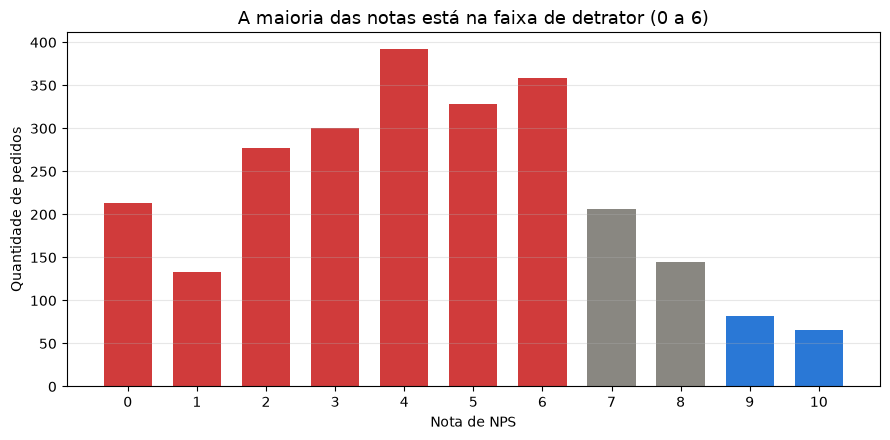

In [ ]:
# --- Gráfico 1: como as notas se distribuem ---------------------------------
figura, eixo = plt.subplots(figsize=(9, 4.5))

# Uma barra para cada nota inteira, pintada conforme a categoria.
contagem_por_nota = df["nps_score"].round().value_counts().sort_index()
cores = [VERMELHO if nota < 7 else CINZA if nota < 9 else AZUL
         for nota in contagem_por_nota.index]

eixo.bar(contagem_por_nota.index, contagem_por_nota.values, color=cores, width=0.7)
eixo.set_title("A maioria das notas está na faixa de detrator (0 a 6)", fontsize=13)
eixo.set_xlabel("Nota de NPS")
eixo.set_ylabel("Quantidade de pedidos")
eixo.set_xticks(range(0, 11))
eixo.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/simples-01-notas.png", dpi=150)
plt.show()

### O que isso quer dizer para o negócio

O NPS da empresa é **−80**. De cada 100 pedidos:

- **84 terminam com um cliente detrator**
- 11 com um cliente neutro
- **apenas 4 com um promotor**

Qualquer NPS abaixo de zero já é considerado **zona crítica** no mercado. Aqui não é um caso de
"melhorar um pouco o indicador": a experiência que a empresa está entregando hoje produz
insatisfação na maior parte dos pedidos.

Nas próximas seções descobrimos **o que**, na operação, está derrubando essas notas.

## 5. Pergunta 1 — Quais fatores são mais críticos?

A **correlação** mede se duas colunas se movem juntas. Ela vai de −1 a +1:

- perto de **+1**: quando uma sobe, a outra sobe junto
- perto de **−1**: quando uma sobe, a outra **desce**
- perto de **0**: uma não tem relação com a outra

⚠️ **Correlação não prova causa.** Ela mostra que duas coisas andam juntas, não que uma causa a outra.

In [30]:
# Selecionamos só colunas numéricas e tiramos os identificadores
# (correlação de número de cadastro não significa nada).
colunas_numericas = df.select_dtypes(include="number").columns
colunas_numericas = colunas_numericas.drop(["customer_id", "order_id"])

correlacoes = df[colunas_numericas].corr()["nps_score"]
correlacoes = correlacoes.drop("nps_score").sort_values()

print("Correlação de cada coluna com a nota de NPS:")
print(correlacoes.round(3).to_string())

Correlação de cada coluna com a nota de NPS:
delivery_delay_days         -0.597
complaints_count            -0.497
customer_service_contacts   -0.351
resolution_time_days        -0.191
freight_value               -0.041
customer_age                -0.010
customer_tenure_months      -0.010
delivery_time_days           0.001
items_quantity               0.011
payment_installments         0.024
discount_value               0.025
delivery_attempts            0.028
order_value                  0.037
csat_internal_score          0.564
repeat_purchase_30d          0.570


### Atenção: três colunas não podem ser usadas

Repare que `csat_internal_score` (+0,56) e `repeat_purchase_30d` (+0,57) aparecem com as
correlações positivas mais altas. Isso **não** é uma boa notícia.

Essas duas colunas, junto com `resolution_time_days`, só existem **depois** do momento em que a
empresa precisaria agir:

| Coluna | Quando ela passa a existir |
|---|---|
| `csat_internal_score` | é outra pesquisa, respondida junto com a experiência |
| `repeat_purchase_30d` | só se sabe 30 dias depois do pedido |
| `resolution_time_days` | só se sabe quando o chamado é encerrado |

Usá-las para prever a satisfação seria "adivinhar" o resultado olhando para o próprio resultado.
Isso se chama **vazamento de dados** (*data leakage*). Elas ficam **fora** da nossa análise de
fatores — e um teste rápido mostra o porquê.

In [31]:
# repeat_purchase_30d deveria dizer se o cliente voltou a comprar.
# Testamos se ela é, na verdade, a própria nota convertida em 0 e 1.
teste = (df["repeat_purchase_30d"] == (df["nps_score"] >= 8).astype(int))

print("repeat_purchase_30d é exatamente 'nota maior ou igual a 8'?", teste.all())
print("Acerta em", teste.sum(), "dos", len(df), "pedidos")

repeat_purchase_30d é exatamente 'nota maior ou igual a 8'? True
Acerta em 2500 dos 2500 pedidos


**Acerta em 100% dos casos.** Essa coluna não traz informação nova: ela é a nota de NPS disfarçada.
Confirmado que ela precisa ficar de fora.

### Os fatores que realmente importam

Tirando as três colunas acima, sobram apenas **três** com relação relevante com a nota:

| Fator | Correlação | Leitura |
|---|---|---|
| `delivery_delay_days` (atraso na entrega) | **−0,60** | quanto mais atrasa, menor a nota |
| `complaints_count` (reclamações) | **−0,50** | quanto mais reclama, menor a nota |
| `customer_service_contacts` (contatos com o SAC) | **−0,35** | quanto mais aciona o atendimento, menor a nota |

E um resultado que surpreende: **`delivery_time_days` (o tempo total de entrega) tem correlação
0,00** — ou seja, **nenhuma relação com a nota**.

> **Traduzindo:** o cliente **não** se importa que a entrega demore. Ele se importa que a entrega
> **atrase em relação ao que foi prometido**. Entregar em 14 dias dá a mesma nota que entregar em 2,
> desde que o prazo combinado seja cumprido.

### Tempo total de entrega × atraso: duas medidas diferentes

É importante não confundir `delivery_time_days` com `delivery_delay_days`.

- `delivery_time_days`: quantos dias a entrega levou.
- `delivery_delay_days`: quantos dias a entrega ultrapassou o prazo prometido.

Uma entrega pode levar muitos dias e ainda cumprir o prazo, enquanto outra pode levar menos dias e mesmo assim chegar atrasada. Os resultados sugerem que o cumprimento do prazo prometido pode estar mais associado à satisfação do cliente do que o tempo total de entrega.

In [32]:
tempo_vs_atraso = (
    df.groupby("categoria_nps")
      .agg(
          pedidos=("nps_score", "size"),
          tempo_medio_entrega=("delivery_time_days", "mean"),
          atraso_medio=("delivery_delay_days", "mean")
      )
      .round(2)
)

tempo_vs_atraso

,pedidos,tempo_medio_entrega,atraso_medio
categoria_nps,,,
detrator,2109,7.99,2.41
neutro,281,8.26,1.05
promotor,110,7.94,0.72


Os resultados mostram que o tempo médio total de entrega é bastante semelhante entre promotores e detratores, sendo 7,94 dias para promotores e 7,99 dias para detratores. Em contrapartida, o atraso médio apresenta uma diferença mais significativa, passando de 0,72 dia entre promotores para 2,41 dias entre detratores.

Isso sugere que a insatisfação está mais relacionada ao descumprimento do prazo prometido do que simplesmente ao tempo total que a entrega leva. Esse resultado reforça o atraso como um dos principais fatores associados à experiência negativa do cliente.

## 6. Perguntas 2 e 3 — O que gera detratores e onde está o ponto de ruptura?

Em vez de olhar a nota média, vamos usar a métrica que o negócio entende:
**de cada 100 pedidos nessa situação, quantos terminam com um cliente detrator?**

In [33]:
# groupby agrupa os pedidos por uma coluna e calcula números para cada grupo.
def detratores_por(coluna):
    """Monta uma tabela com nº de pedidos, nota mediana e % de detratores por grupo."""
    tabela = df.groupby(coluna).agg(
        pedidos=("nps_score", "count"),
        nota_mediana=("nps_score", "median"),
        percentual_detratores=("eh_detrator", "mean"),
    )
    tabela["percentual_detratores"] = (tabela["percentual_detratores"] * 100).round(1)
    return tabela.round(2)


tabela_atraso = detratores_por("delivery_delay_days")
tabela_atraso

,pedidos,nota_mediana,percentual_detratores
delivery_delay_days,,,
0,277,6.80,51.6
1,615,5.50,74.0
2,646,4.60,87.9
3,525,3.40,96.8
4,270,2.30,99.3
5,116,1.25,100.0
6,34,0.70,100.0
7,14,0.00,100.0
8,3,0.00,100.0


Como ler: a coluna **`pedidos`** é o tamanho do grupo — repare que as últimas linhas têm
pouquíssimos pedidos (34, 14, 3), então esses percentuais não são confiáveis. A leitura firme está
nas linhas de 0 a 4 dias, que juntas somam 2.333 dos 2.500 pedidos.

### Ponto de ruptura: olhando também o tamanho de cada grupo

O percentual de detratores precisa ser analisado junto com a quantidade de pedidos. Um grupo com poucos pedidos pode apresentar 100% de detratores sem representar um padrão relevante para toda a operação.

Por isso, usamos a tabela abaixo para deixar o tamanho da amostra explícito e concentrar a leitura nos grupos com volume suficiente.

In [34]:
ruptura_atraso = (
    tabela_atraso[["pedidos", "percentual_detratores"]]
    .copy()
)

ruptura_atraso

,pedidos,percentual_detratores
delivery_delay_days,,
0,277,51.6
1,615,74.0
2,646,87.9
3,525,96.8
4,270,99.3
5,116,100.0
6,34,100.0
7,14,100.0
8,3,100.0


### **Conclusão — Ponto de ruptura**

> A análise mostra uma forte relação entre o atraso na entrega e a concentração de detratores. Sem atraso, **51,6% dos clientes são detratores**, enquanto com apenas 1 dia de atraso esse percentual sobe para **74,0%**.
>
> Esse comportamento se intensifica conforme o atraso aumenta: **87,9% dos clientes são detratores com 2 dias de atraso, 96,8% com 3 dias e 99,3% com 4 dias**.
>
> Dessa forma, os resultados indicam que **o atraso é um fator crítico para a satisfação**, com uma piora significativa já no primeiro dia e uma situação ainda mais crítica a partir de 3 dias de atraso.

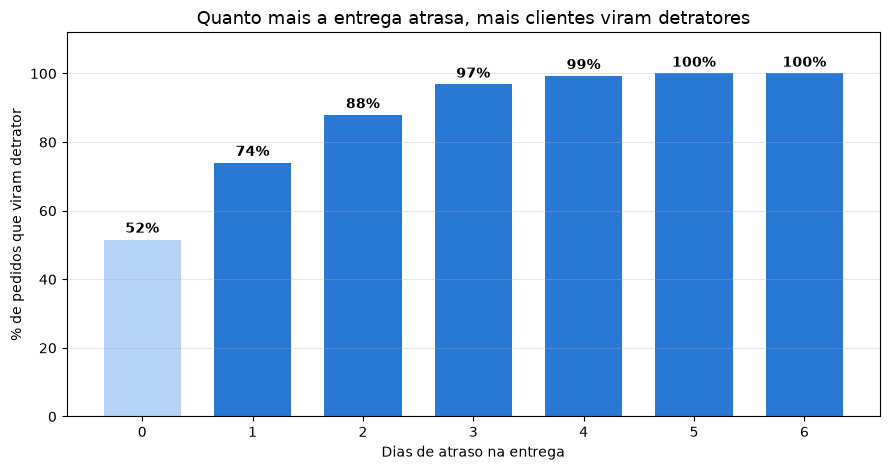

In [ ]:
# --- Gráfico 2: o efeito do atraso na entrega -------------------------------
# Usamos só os grupos com pelo menos 30 pedidos.
dados = tabela_atraso[tabela_atraso["pedidos"] >= 30]

figura, eixo = plt.subplots(figsize=(9, 4.8))

# A primeira barra (sem atraso) fica clara; as demais em azul forte,
# para destacar o salto que acontece já no primeiro dia.
cores = [AZUL_CLARO] + [AZUL] * (len(dados) - 1)
eixo.bar(dados.index, dados["percentual_detratores"], color=cores, width=0.7)

# Escreve a porcentagem em cima de cada barra.
for dia, valor in zip(dados.index, dados["percentual_detratores"]):
    eixo.text(dia, valor + 2, f"{valor:.0f}%", ha="center", fontweight="bold")

eixo.set_title("Quanto mais a entrega atrasa, mais clientes viram detratores", fontsize=13)
eixo.set_xlabel("Dias de atraso na entrega")
eixo.set_ylabel("% de pedidos que viram detrator")
eixo.set_ylim(0, 112)
eixo.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/simples-02-atraso.png", dpi=150)
plt.show()

### O ponto de ruptura é o **primeiro dia de atraso**

| Atraso | % de detratores | Quanto piorou (em % de detratores) |
|---|---|---|
| Sem atraso | 52% | — |
| **1 dia** | **74%** | **+22 pontos percentuais** |
| 2 dias | 88% | +14 pontos percentuais |
| 3 dias | 97% | +9 pontos percentuais |
| 4 dias | 99% | +2 pontos percentuais |

O maior salto acontece **logo no primeiro dia**. Depois disso o estrago vai ficando menor, porque o
cliente já está perdido.

> **Isso inverte a intuição da operação.** O instinto é correr atrás dos casos mais graves — os
> atrasos de 5 ou 6 dias. Mas esses são poucos (**6,7% dos pedidos**) e já estão 100% perdidos.
> O volume está entre **1 e 2 dias de atraso: metade de todos os pedidos**. É ali que ainda existe
> cliente para salvar.

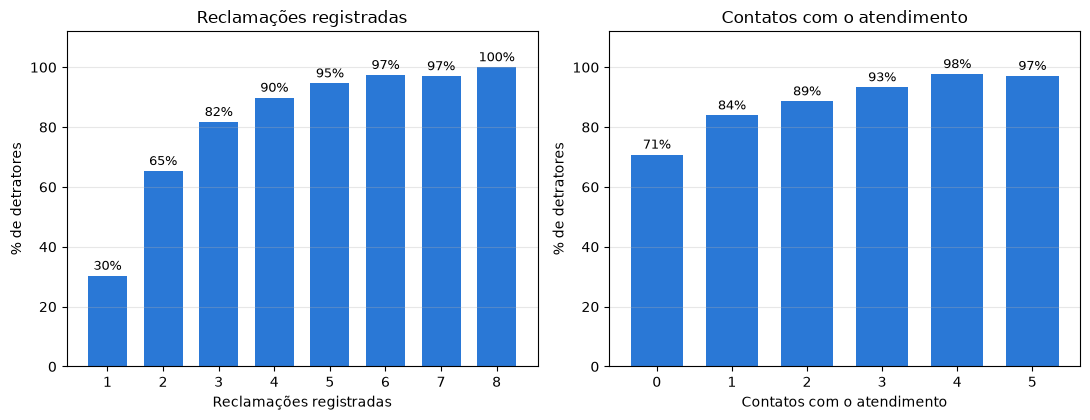

In [ ]:
# --- Gráfico 3: reclamações e contatos com o atendimento --------------------
figura, eixos = plt.subplots(1, 2, figsize=(11, 4.3))

graficos = [
    ("complaints_count", "Reclamações registradas", eixos[0]),
    ("customer_service_contacts", "Contatos com o atendimento", eixos[1]),
]

for coluna, titulo, eixo in graficos:
    tabela = detratores_por(coluna)
    tabela = tabela[tabela["pedidos"] >= 30]   # ignora grupos pequenos demais

    eixo.bar(tabela.index, tabela["percentual_detratores"], color=AZUL, width=0.7)
    for x, valor in zip(tabela.index, tabela["percentual_detratores"]):
        eixo.text(x, valor + 2, f"{valor:.0f}%", ha="center", fontsize=9)

    eixo.set_title(titulo, fontsize=12)
    eixo.set_xlabel(titulo)
    eixo.set_ylabel("% de detratores")
    eixo.set_ylim(0, 112)
    eixo.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/simples-03-atendimento.png", dpi=150)
plt.show()

### O mesmo padrão no atendimento

- **Reclamações:** com 1 reclamação, 30% viram detratores. Com **2**, salta para **65%**.
- **Contatos com o SAC:** sem nenhum contato, 71%. Com **1 contato**, **84%**.

De novo: **a primeira falha é a que mais custa.**

⚠️ Uma ressalva honesta sobre as reclamações: os clientes que quase não reclamam são, em boa parte,
os mesmos cujo pedido não atrasou. Então parte dessa queda é o atraso "viajando junto" com a
reclamação. O efeito da reclamação existe, mas é menor do que a tabela sozinha sugere.

In [37]:
# As duas falhas se somam? Cruzamos atraso com contatos ao atendimento.
# pd.cut agrupa números em faixas, para a tabela não ficar gigante.
df["faixa_atraso"] = pd.cut(df["delivery_delay_days"],
                            bins=[-1, 0, 1, 2, 3, 99],
                            labels=["Sem atraso", "1 dia", "2 dias", "3 dias", "4+ dias"])
df["faixa_contatos"] = pd.cut(df["customer_service_contacts"],
                              bins=[-1, 0, 1, 2, 99],
                              labels=["Nenhum", "1 contato", "2 contatos", "3+ contatos"])

cruzamento = df.pivot_table(index="faixa_atraso", columns="faixa_contatos",
                            values="eh_detrator", aggfunc="mean", observed=True)
print("% de detratores por combinação de falhas:")
(cruzamento * 100).round(0)

% de detratores por combinação de falhas:


faixa_contatos,Nenhum,1 contato,2 contatos,3+ contatos
faixa_atraso,,,,
Sem atraso,22.0,45.0,64.0,79.0
1 dia,58.0,69.0,79.0,93.0
2 dias,71.0,89.0,93.0,97.0
3 dias,89.0,99.0,99.0,100.0
4+ dias,98.0,100.0,100.0,100.0


### As falhas se somam

A tabela se lê do canto de cima à esquerda para o de baixo à direita:

- **entrega no prazo e nenhum contato com o SAC → 22% de detratores** (o melhor cenário da operação);
- **4+ dias de atraso e 3+ contatos → 100%** (não sobra ninguém);
- e, mesmo com a **entrega em dia**, cada contato ao atendimento acrescenta entre 15 e 23 pontos
  percentuais (22% → 45% → 64% → 79%) — de novo, o primeiro custa mais que o último.

> **Não adianta consertar só uma frente.** Um atendimento ruim destrói uma entrega boa.

## 7. Pergunta 4 — Que tipo de cliente tem NPS mais alto ou mais baixo?

Aqui a resposta é surpreendente — e é importante mostrá-la com dados, em vez de inventar um perfil
que não existe.

In [38]:
# Agrupamos os clientes por região, idade e tempo de casa
# e vemos se algum desses grupos escapa da média.
df["faixa_idade"] = pd.cut(df["customer_age"], bins=[17, 30, 45, 60, 100],
                           labels=["18-30", "31-45", "46-60", "60+"])

# tempo de casa (tenure), na mesma lógica das outras faixas: quartis aproximados
# do próprio período coberto pela base (1 a 119 meses).
df["faixa_tenure"] = pd.cut(df["customer_tenure_months"], bins=[0, 24, 60, 96, 120],
                            labels=["até 2 anos", "2-5 anos", "5-8 anos", "8+ anos"])

for coluna in ["customer_region", "faixa_idade", "faixa_tenure"]:
    tabela = df.groupby(coluna, observed=True).agg(
        pedidos=("nps_score", "count"),
        nota_mediana=("nps_score", "median"),
        percentual_detratores=("eh_detrator", "mean"),
    )
    tabela["percentual_detratores"] = (tabela["percentual_detratores"] * 100).round(1)
    print(f"--- {coluna} ---")
    print(tabela.round(2).to_string())
    print()

--- customer_region ---
                 pedidos  nota_mediana  percentual_detratores
customer_region                                              
Centro-Oeste         468           4.2                   84.2
Nordeste             485           4.5                   85.6
Norte                506           4.5                   85.2
Sudeste              520           4.3                   83.7
Sul                  521           4.5                   83.3

--- faixa_idade ---
             pedidos  nota_mediana  percentual_detratores
faixa_idade                                              
18-30            602           4.5                   82.6
31-45            769           4.3                   86.5
46-60            714           4.4                   85.0
60+              415           4.5                   81.9

--- faixa_tenure ---
              pedidos  nota_mediana  percentual_detratores
faixa_tenure                                              
até 2 anos        489           4

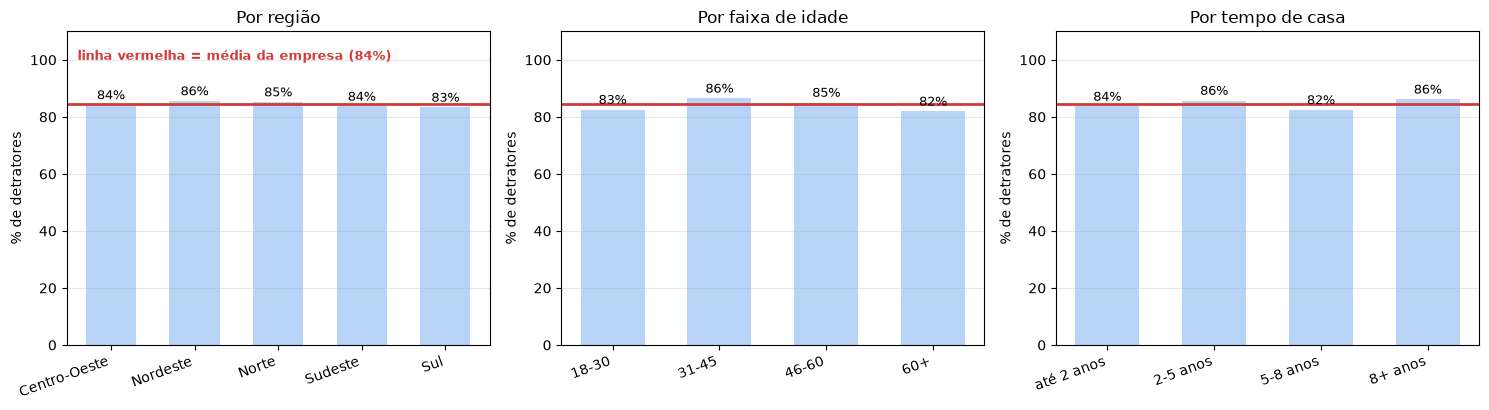

In [ ]:
# --- Gráfico 4: o perfil do cliente não separa nada -------------------------
figura, eixos = plt.subplots(1, 3, figsize=(15, 4.2))

comparacoes = [
    ("customer_region", "Por região", eixos[0]),
    ("faixa_idade", "Por faixa de idade", eixos[1]),
    ("faixa_tenure", "Por tempo de casa", eixos[2]),
]
media_geral = df["eh_detrator"].mean() * 100

for coluna, titulo, eixo in comparacoes:
    valores = df.groupby(coluna, observed=True)["eh_detrator"].mean() * 100

    eixo.bar(range(len(valores)), valores.values, color=AZUL_CLARO, width=0.6)
    for i, valor in enumerate(valores.values):
        eixo.text(i, valor + 2, f"{valor:.0f}%", ha="center", fontsize=9)

    # Linha vermelha: a média da empresa inteira.
    eixo.axhline(media_geral, color=VERMELHO, linewidth=2)

    eixo.set_xticks(range(len(valores)))
    eixo.set_xticklabels(valores.index, rotation=20, ha="right")
    eixo.set_title(titulo, fontsize=12)
    eixo.set_ylabel("% de detratores")
    eixo.set_ylim(0, 110)
    eixo.grid(axis="y", alpha=0.3)

eixos[0].text(-0.4, 100, f"linha vermelha = média da empresa ({media_geral:.0f}%)",
              color=VERMELHO, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/simples-04-perfil.png", dpi=150)
plt.show()

### Não existe "cliente detrator" — existe "experiência detratora"

Todas as regiões ficam entre 83% e 86% de detratores. Todas as faixas de idade, entre 82% e 86%.
Ou seja: **coladas na média da empresa**.

Compare as diferenças:

| Se eu separar os clientes por... | Diferença entre o melhor e o pior grupo |
|---|---|
| Região | **2 pontos percentuais** |
| Faixa de idade | **4 pontos percentuais** |
| **Dias de atraso na entrega** | **48 pontos percentuais** |

Um cliente do Sul, de 50 anos, com 8 anos de casa, vira detrator na mesma proporção que qualquer
outro **quando o pedido dele atrasa**.

> **Consequência prática:** fazer campanha de relacionamento segmentada por região ou faixa etária
> **não vai mover o NPS**. O que move é consertar o pedido, não escolher o cliente.

E isso explica o enigma que abriu o case — *"clientes parecidos viram promotores ou detratores"*:
o que os separa não está no cadastro, está na execução do pedido.

## 8. Conclusões e recomendações

### As respostas às quatro perguntas

| Pergunta | Resposta |
|---|---|
| **Quais fatores são mais críticos?** | Atraso na entrega (−0,60), reclamações (−0,50) e contatos com o atendimento (−0,35). |
| **O que mais gera detratores?** | A experiência de entrega, principalmente quando o prazo prometido é quebrado. |
| **Existe ponto de ruptura?** | Sim. O primeiro dia de atraso já representa um salto importante na proporção de detratores; com 3 dias, a proporção chega a aproximadamente 97%. |
| **Que tipo de cliente tem NPS mais alto ou mais baixo?** | Idade, região e tempo de relacionamento ajudam a descrever a base, mas apresentam diferenças muito menores que os fatores operacionais. |

### Síntese

O NPS da empresa é **−80**, com aproximadamente **84% de detratores**. A análise exploratória indica que a principal oportunidade está na experiência operacional: atrasos, reclamações, contatos com atendimento e dificuldades na conclusão da entrega aparecem associados a uma pior avaliação.

O principal ponto de atenção é o **cumprimento do prazo prometido**. Por isso, as recomendações devem priorizar a prevenção de atrasos e o acompanhamento dos pedidos que apresentem sinais de risco.

> **Importante:** os resultados mostram associações observadas na base; eles não permitem afirmar causalidade isoladamente.

### Recomendações

1. Priorizar o cumprimento do prazo prometido.
2. Criar alertas para pedidos que estejam se aproximando do limite de atraso.
3. Investigar as causas de múltiplas tentativas de entrega.
4. Monitorar reclamações e contatos com atendimento como sinais de deterioração da experiência.
5. Em uma futura modelagem preditiva, utilizar apenas informações disponíveis antes do momento em que o NPS seria previsto.


In [ ]:
# Salva a base com as colunas que criamos, para reaproveitar depois.
df.to_csv("../data/processed/nps_tratado_simples.csv", index=False)
print("Base salva em ../data/processed/nps_tratado_simples.csv")
print("Colunas criadas nesta análise: categoria_nps, eh_detrator, faixa_atraso, "
      "faixa_contatos, faixa_idade")

Base salva em data/processed/nps_tratado_simples.csv
Colunas criadas nesta análise: categoria_nps, eh_detrator, faixa_atraso, faixa_contatos, faixa_idade
